In [1]:
import pandas as pd
import numpy as np
import sys
from anndata import AnnData
import scanpy as sc
import warnings
from matplotlib import pyplot as plt
import seaborn as sns

# sys.path.append('../../spatialcorr')

import spatialcorr

warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
#########################CRC spatial #############################

In [3]:
import scanpy as sc

# 파일 경로 설정
matrix_path = "/home/Data_Drive_8TB_3/Coloncancer/Visium/Hackathon_Data/VisiumHD_SampleP1_CRC/binned_outputs/square_016um/filtered_feature_bc_matrix/matrix.mtx.gz"
barcodes_path = "/home/Data_Drive_8TB_3/Coloncancer/Visium/Hackathon_Data/VisiumHD_SampleP1_CRC/binned_outputs/square_016um/filtered_feature_bc_matrix/barcodes.tsv.gz"
features_path = "/home/Data_Drive_8TB_3/Coloncancer/Visium/Hackathon_Data/VisiumHD_SampleP1_CRC/binned_outputs/square_016um/filtered_feature_bc_matrix/features.tsv.gz"

# 10x 형식의 공간 데이터를 불러오기
adata = sc.read_10x_mtx(
    "/home/Data_Drive_8TB_3/Coloncancer/Visium/Hackathon_Data/VisiumHD_SampleP1_CRC/binned_outputs/square_016um/filtered_feature_bc_matrix/",
    var_names="gene_symbols",  # 'features' 파일에서 유전자 이름을 사용할 수 있도록 설정
    cache=True
)

import pandas as pd
# tissue_positions.csv 파일 경로
tissue_positions_path = "/home/Data_Drive_8TB_3/Coloncancer/Visium/Hackathon_Data/VisiumHD_SampleP1_CRC/binned_outputs/square_016um/spatial/tissue_positions.csv"

# CSV 파일을 로드하여 좌표 정보 추출
tissue_positions = pd.read_csv(tissue_positions_path)
import pandas as pd
import numpy as np

# tissue_positions.csv 파일 경로
tissue_positions_path = "/home/Data_Drive_8TB_3/Coloncancer/Visium/Hackathon_Data/VisiumHD_SampleP1_CRC/binned_outputs/square_016um/spatial/tissue_positions.csv"

# tissue_positions 데이터 로드
tissue_positions = pd.read_csv(tissue_positions_path)

# tissue_positions의 'barcode'를 인덱스로 설정
tissue_positions.set_index('barcode', inplace=True)

# adata의 인덱스와 tissue_positions의 barcode를 매칭
spatial_coords = []

for idx in adata.obs.index:
    try:
        # adata.obs의 인덱스(즉, barcode)와 tissue_positions의 barcode를 매칭하여 좌표 추출
        coord = tissue_positions.loc[idx, ['pxl_row_in_fullres', 'pxl_col_in_fullres']].values
        spatial_coords.append(coord)
    except KeyError:
        # 매칭되지 않으면 NaN 처리
        spatial_coords.append([np.nan, np.nan])

# 공간 좌표를 adata.obsm["spatial"]에 저장
adata.obsm["spatial"] = np.array(spatial_coords)

# 공간 좌표 데이터 확인
print(adata.obsm["spatial"])

[[33582.69326014  4592.15436107]
 [36191.27431535 21222.63654042]
 [27266.74658155 23176.07685251]
 ...
 [34392.67393682 10019.17216598]
 [34519.28391308 11069.86132274]
 [28339.41698439 19075.18704122]]


In [4]:
import scanpy as sc
scadata = sc.read_h5ad('/home/Data_Drive_8TB_3/Coloncancer/Temp_Rds/total_CRC_final_counts_active.h5ad')
print(adata.shape)  # adata.shape는 튜플 형태로 출력됩니다.

(127809, 18085)


In [5]:
import matplotlib as mpl

scadata.var["mt"] = scadata.var_names.str.startswith("MT-")
scadata.obsm['mt'] = scadata[:, scadata.var['mt'].values].X.toarray()
scadata = scadata[:, ~scadata.var['mt'].values]

/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/cell2location/utils/filtering.py:26: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = np.array((adata.X > 0).sum(0)).flatten()
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


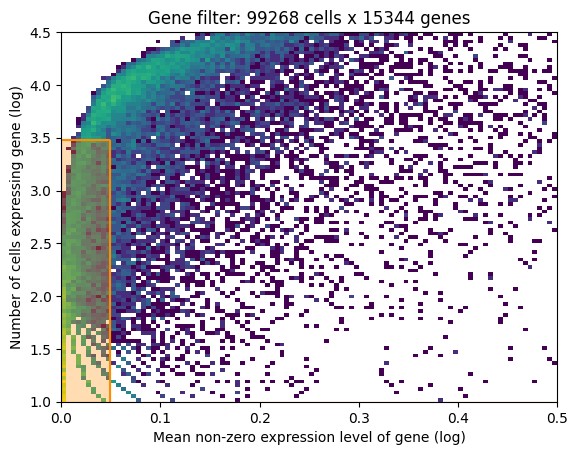

In [6]:
import cell2location
from cell2location.utils.filtering import filter_genes
selected = filter_genes(scadata, cell_count_cutoff=5, cell_percentage_cutoff2=0.03, nonz_mean_cutoff=1.12)

# filter the object
adata_ref = scadata[:, selected].copy()

In [7]:
cell2location.models.RegressionModel.setup_anndata(adata=adata_ref,
                        # 10X reaction / sample / batch
                        # cell type, covariate used for constructing signatures
                        labels_key='annotation'
                        # multiplicative technical effects (platform, 3' vs 5', donor effect)
                       )



In [8]:
from cell2location.models import RegressionModel
mod = RegressionModel(adata_ref)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.2.1.

Setup via `RegressionModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': 'annotation',
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics         
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃     Summary Stat Key     ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│         n_batch          │   1   │
│         n_cells          │ 99268 │
│ n_extra_categorical_covs │   0   │
│ n_extra_continuous_covs  │   0   │
│         n_labels         │   9   │
│          n_vars          │ 15344 │
└──────────────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                      labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location     ┃  Categories   ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['annotation'] │  Epithelial   │          0          │
│                         │     T/NK      │          1          │
│                         │    Myeloid    │          2          │
│                         │     CD19B     │          3          │
│                         │    plasmaB    │          4          │
│                         │ Cycling cells │          5          │
│                         │  Fibroblasts  │          6          │
│                         │  Endothelial  │          7          │
│                         │     Mast      │          8          │
└─────────────────────────┴───────────────┴─────────────────────┘

In [9]:
import cell2location
from cell2location.models import RegressionModel

mod.train(max_epochs=250, accelerator='cpu')

/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/user/anaconda3/envs/kykim/lib/python3.12/site- ...
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/user/anaconda3/envs/kykim/lib/python3.12/site- ...
/h

Epoch 250/250: 100%|██████████| 250/250 [4:33:48<00:00, 64.41s/it, v_num=1, elbo_train=6.32e+8]  

`Trainer.fit` stopped: `max_epochs=250` reached.


Epoch 250/250: 100%|██████████| 250/250 [4:33:48<00:00, 65.71s/it, v_num=1, elbo_train=6.32e+8]


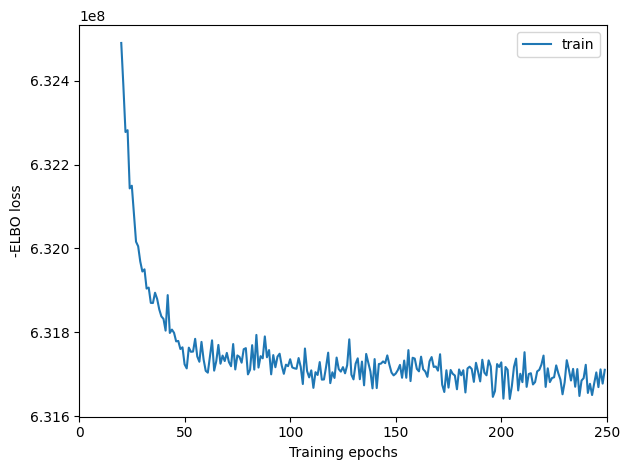

In [10]:
mod.plot_history(20)

In [11]:
adata_ref = mod.export_posterior(
    adata_ref, sample_kwargs={'num_samples': 1000, 'batch_size': 2500}
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/user/anaconda3/envs/kykim/lib/python3.12/site- ...


Sampling global variables, sample: 100%|██████████| 999/999 [00:07<00:00, 131.13it/s]


In [12]:
# export estimated expression in each cluster
if 'means_per_cluster_mu_fg' in adata_ref.varm.keys():
    inf_aver = adata_ref.varm['means_per_cluster_mu_fg'][[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
else:
    inf_aver = adata_ref.var[[f'means_per_cluster_mu_fg_{i}'
                                    for i in adata_ref.uns['mod']['factor_names']]].copy()
inf_aver.columns = adata_ref.uns['mod']['factor_names']
inf_aver.iloc[0:5, 0:5]

,Epithelial,T/NK,Myeloid,CD19B,plasmaB
AL645608.7,0.000093,0.000006,0.000022,0.000044,0.000044
SAMD11,0.000177,0.000130,0.000354,0.000036,0.003602
NOC2L,0.123828,0.051973,0.067701,0.059104,0.091484
AL645608.8,0.003876,0.000404,0.009190,0.000368,0.000324
HES4,0.102389,0.017195,0.150715,0.013719,0.008119


In [13]:
# find shared genes and subset both anndata and reference signatures
# 여기서부터 slide 교체#

# adata.var_names_make_unique() 
inf_aver = inf_aver.loc[~inf_aver.index.duplicated()].copy()  # inf_aver에서 중복 유전자명 제거

intersect = np.intersect1d(adata.var_names, inf_aver.index)
adata = adata[:, intersect].copy()
inf_aver = inf_aver.loc[intersect, :].copy()

# prepare anndata for cell2location model
cell2location.models.Cell2location.setup_anndata(adata)

/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)


In [14]:
inf_aver

,Epithelial,T/NK,Myeloid,CD19B,plasmaB,Cycling cells,Fibroblasts,Endothelial,Mast
A1CF,0.030481,0.000111,0.000211,0.000091,0.000455,0.013576,0.001018,0.001310,0.000177
A2M,0.003364,0.000366,0.262538,0.000369,0.001898,0.002532,2.138106,3.289194,0.006864
A4GALT,0.002408,0.001816,0.002781,0.004202,0.000790,0.011044,0.200109,0.139065,0.000292
AAAS,0.047671,0.018588,0.033078,0.016016,0.066820,0.099473,0.073322,0.041904,0.021898
AACS,0.036600,0.008308,0.010560,0.007133,0.024066,0.043100,0.032018,0.015561,0.017588
...,...,...,...,...,...,...,...,...,...
ZXDB,0.019902,0.007550,0.005082,0.011054,0.010059,0.013473,0.014034,0.017642,0.005081
ZXDC,0.033753,0.024767,0.026382,0.027055,0.016778,0.046632,0.036775,0.033558,0.019080
ZYG11B,0.019700,0.006540,0.020044,0.011258,0.011683,0.017889,0.059371,0.057175,0.015003
ZYX,0.286448,0.211259,0.721945,0.072251,0.060930,0.562152,0.677164,0.730054,0.122752


In [15]:

mod = cell2location.models.Cell2location(
    adata, cell_state_df=inf_aver,
    # the expected average cell abundance: tissue-dependent
    # hyper-prior which can be estimated from paired histology:
    N_cells_per_location=30,
    # hyperparameter controlling normalisation of
    # within-experiment variation in RNA detection:
    detection_alpha=20
)
mod.view_anndata_setup()

Anndata setup with scvi-tools version 1.2.1.

Setup via `Cell2location.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   1    │
│         n_cells          │ 127809 │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   1    │
│          n_vars          │ 13243  │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

In [32]:
mod.train(max_epochs=300,
          # train using full data (batch_size=None)
          batch_size=64,
          # use all data points in training because
          # we need to estimate cell abundance at all locations
          train_size= 1
         )

/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/scvi/dataloaders/_data_splitting.py:258: UserWarning: Last batch will have a small size of 1 samples. Consider changing settings.batch_size or batch_size in model.train from currently 64 to avoid errors during model training.
  self.n_train, self.n_val = validate_data_split(
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/user/anaconda3/envs/kykim/lib/python3.12/site- ...
GPU available: True (cuda), used: 

Epoch 205/300:  68%|██████▊   | 204/300 [11:24:34<5:22:30, 201.57s/it, v_num=1, elbo_train=3.69e+12]

ValueError: Expected parameter loc (Parameter of shape (1, 13243)) of distribution Normal(loc: torch.Size([1, 13243]), scale: torch.Size([1, 13243])) to satisfy the constraint Real(), but found invalid values:
Parameter containing:
tensor([[-0.1003, -0.0730,  0.1911,  ..., -0.1744, -0.8189, -0.0318]],
       device='cuda:0', requires_grad=True)
                              Trace Shapes:                          
                               Param Sites:                          
                   AutoNormal.locs.m_g_mean          1     1         
                 AutoNormal.scales.m_g_mean          1     1         
            AutoNormal.locs.m_g_alpha_e_inv          1     1         
          AutoNormal.scales.m_g_alpha_e_inv          1     1         
                        AutoNormal.locs.m_g          1 13243         
                      AutoNormal.scales.m_g          1 13243         
     AutoNormal.locs.n_s_cells_per_location     127809     1         
   AutoNormal.scales.n_

In [39]:
adata_vis = mod.export_posterior(
    adata, sample_kwargs={'num_samples': 1000, 'batch_size': mod.adata.n_obs})

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


Sampling local variables, batch:   0%|          | 0/1 [00:03<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 6.31 GiB. GPU 0 has a total capacity of 23.67 GiB of which 3.82 GiB is free. Including non-PyTorch memory, this process has 19.84 GiB memory in use. Of the allocated memory 13.40 GiB is allocated by PyTorch, and 6.18 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [106]:
# model_save_path = "/home/Data_Drive_8TB_3/kykim/colon/SN048_A121573_Rep2/"
# mod.save(model_save_path)

In [107]:
adata.var.drop(columns=['SYMBOL'], inplace=True)


In [108]:
# The model and output h5ad can be loaded later like this:

# adata_file = f"{run_name}/sp.h5ad"
# # adata_vis = sc.read_h5ad(adata_file)
# # mod = cell2location.models.Cell2location.load(f"{run_name}", adata_vis)

In [40]:
mod.plot_QC()

/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/cell2location/models/base/_pyro_mixin.py:487: SyntaxWarning: invalid escape sequence '\.'
  """Export posterior distribution summary for observation-specific parameters


RuntimeError: self.samples is missing, please run self.export_posterior() first

In [ ]:
adata_vis.obs[adata_vis.uns['mod']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']


In [ ]:
save_path = "/home/Data_Drive_8TB_3/kykim/colon/Visium HD/VisiumHD_SampleP1_CRC_Deconvolution.h5ad"

# adata_vis를 지정된 경로에 저장
adata_vis.write(save_path)
print("adata_vis saved successfully at:", save_path)

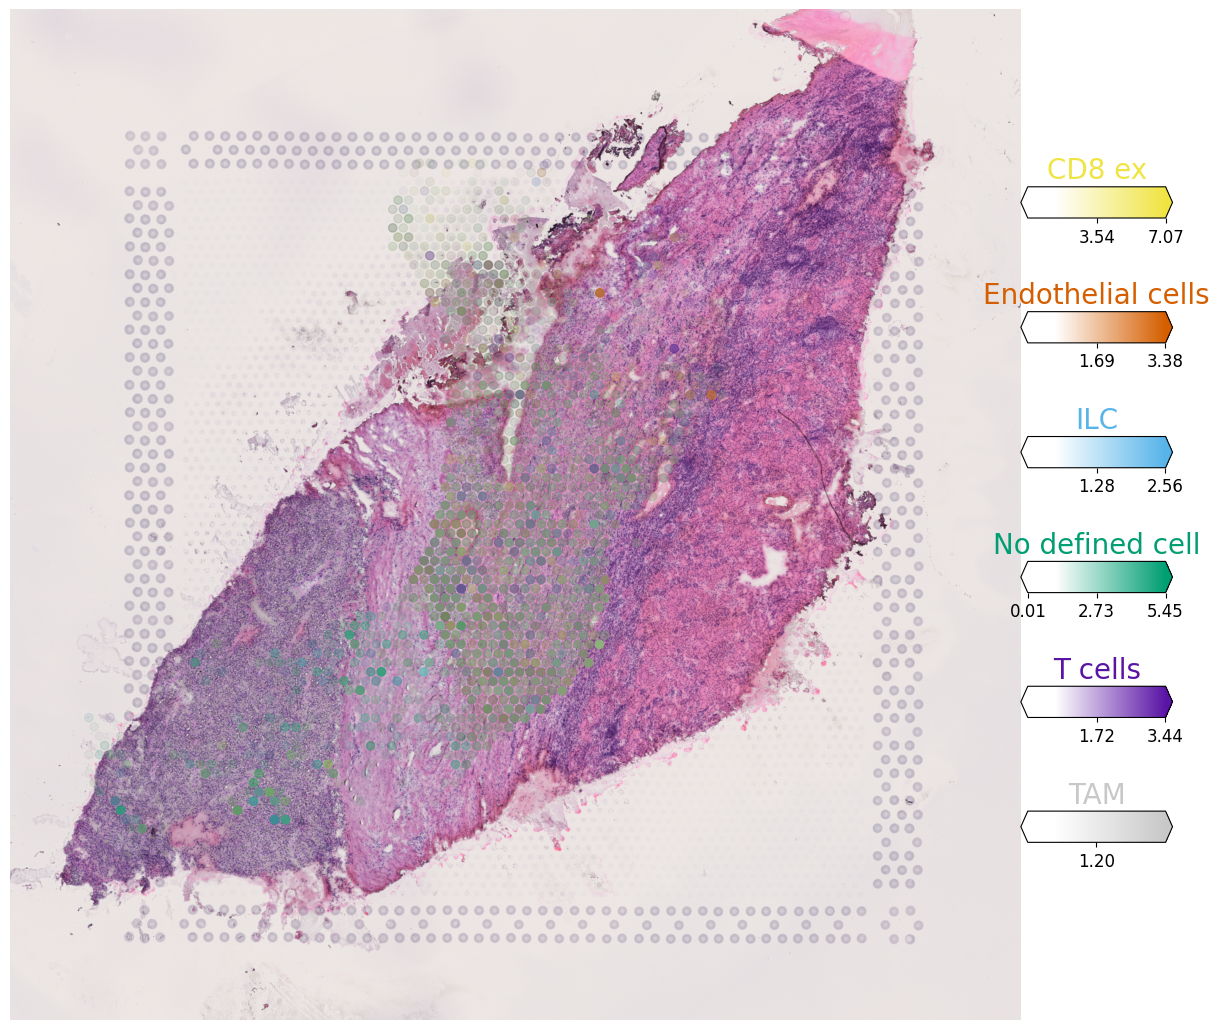

In [112]:
from cell2location.plt import plot_spatial

clust_labels = ['CD8 ex','Endothelial cells','ILC','No defined cell','T cells','TAM']
clust_col = ['' + str(i) for i in clust_labels]

with mpl.rc_context({'figure.figsize': (15, 15)}):
    fig = plot_spatial(
        adata=adata_vis,
        # labels to show on a plot
        color=clust_col, labels=clust_labels,
        show_img=True,
        # 'fast' (white background) or 'dark_background'
        style='fast',
        # limit color scale at 99.2% quantile of cell abundance
        max_color_quantile=0.992,
        # size of locations (adjust depending on figure size)
        circle_diameter=6,
        colorbar_position='right'
    )



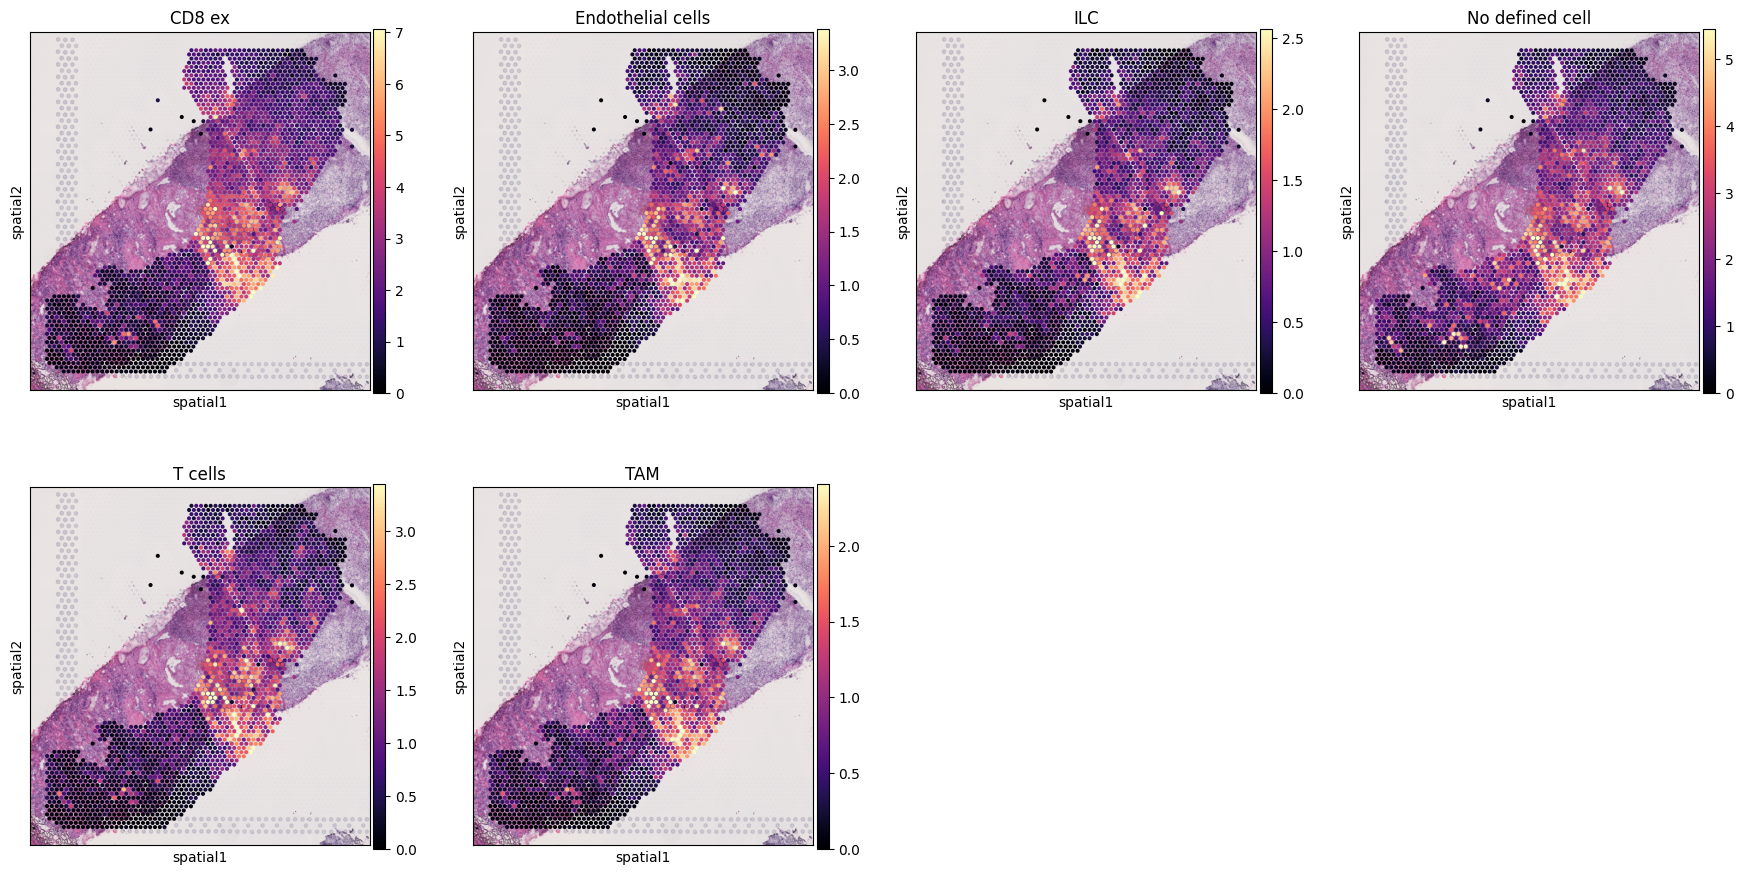

In [113]:
with mpl.rc_context({'axes.facecolor':  'black',
                     'figure.figsize': [4.5, 5]}):

    
    sc.pl.spatial(adata_vis, cmap='magma',
              color=['CD8 ex','Endothelial cells','ILC','No defined cell','T cells','TAM'
],
              ncols=4, size=1.3,
              img_key='hires',
              vmin=0, vmax='p99.2',
              library_id='spaceranger130_count_44316_6800STDY12499502_GRCh38-2020-A')

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
/home/user/anaconda3/envs/kykim/lib/python3.12/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/user/anaconda3/envs/kykim/lib/python3.12/site- ...


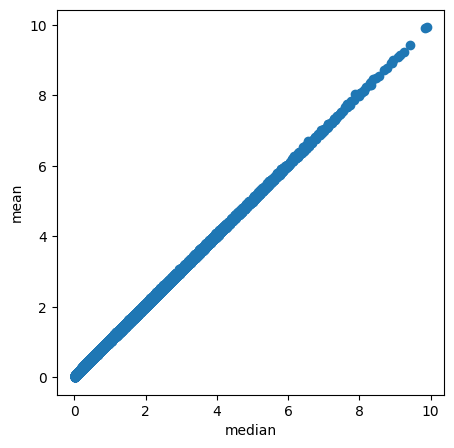

In [114]:
medians = mod.posterior_quantile(q=0.5, batch_size=mod.adata.n_obs)

with mpl.rc_context({'axes.facecolor':  'white',
                     'figure.figsize': [5, 5]}):
    plt.scatter(medians['w_sf'].flatten(), mod.samples['post_sample_means']['w_sf'].flatten());
    plt.xlabel('median');
    plt.ylabel('mean');

In [34]:
adata

AnnData object with n_obs × n_vars = 127809 × 13243
    obs: '_indices', '_scvi_batch', '_scvi_labels'
    var: 'gene_ids', 'feature_types'
    uns: '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'spatial'